# IMDB Movie Review Sentiment Analysis Using Simple RNN

This notebook builds, trains, evaluates, and saves a Simple RNN model for binary sentiment classification on the IMDB movie review dataset.

### Notebook Objectives

1. Load and inspect the IMDB dataset
2. Understand integer-encoded reviews and labels
3. Decode a sample review for interpretation
4. Pad variable-length reviews to a fixed sequence length
5. Build a Simple RNN with an Embedding layer
6. Compile and train the model with Early Stopping
7. Visualize training and validation performance
8. Evaluate the trained model on the held-out test set
9. Save the trained model inside the project's `models/` directory

> **Portfolio note:** The original tutorial uses `input_length` inside `Embedding`. In the current Keras API that argument is deprecated, so this notebook defines the input shape explicitly with `Input(...)`.

## 1. Import Required Libraries

In [53]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load the IMDB Dataset

The IMDB dataset is a binary sentiment classification dataset containing **25,000 training reviews** and **25,000 testing reviews**.

The reviews are provided as sequences of integer token IDs. The labels are:

- `0` → Negative
- `1` → Positive

We limit the vocabulary to the most frequent **10,000 words**.

In [54]:
max_features = 10_000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=max_features
)

print(f"Training reviews shape: {X_train.shape}")
print(f"Training labels shape:  {y_train.shape}")
print(f"Testing reviews shape:  {X_test.shape}")
print(f"Testing labels shape:   {y_test.shape}")

Training reviews shape: (25000,)
Training labels shape:  (25000,)
Testing reviews shape:  (25000,)
Testing labels shape:   (25000,)


## 3. Inspect a Sample Review

The IMDB dataset stores each review as a sequence of integers rather than raw text.

Each integer corresponds to a token in the IMDB vocabulary. The first few values can therefore be inspected directly before decoding the review back to text.

In [55]:
# Inspect a sample review and its label
sample_review = X_train[0]
sample_label = y_train[0]

print(f"Sample review (as integers):{sample_review}")
print(f'Sample label: {sample_label}')

Sample review (as integers):[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample label: 1


## 4. Decode the Sample Review

For interpretability, the IMDB word index can be reversed so that token IDs can be mapped back to words.

The IMDB format reserves special indices, so the `-3` offset is applied during decoding.

In [56]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

decoded_review = " ".join(
    reverse_word_index.get(token_id - 3, "?")
    for token_id in sample_review
)

print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [57]:
decoded_review = " ".join(
    reverse_word_index.get(token_id - 3, "?")
    for token_id in sample_review
)

print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

## 5. Pad the Review Sequences

Different reviews contain different numbers of tokens. A neural network processes batches efficiently when the sequence length is consistent.

We therefore pad every review to a fixed length of **500 tokens**.

The default padding strategy here is **pre-padding**, which adds zeros to the beginning of shorter sequences.

In [58]:
max_length = 500

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="pre"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="pre"
)

print("Padded training shape:", X_train.shape)
print("Padded testing shape: ", X_test.shape)
print("First padded review shape:", X_train[0].shape)

Padded training shape: (25000, 500)
Padded testing shape:  (25000, 500)
First padded review shape: (500,)


In [59]:
X_train

array([[   0,    0,    0, ...,   19,  178,   32],
       [   0,    0,    0, ...,   16,  145,   95],
       [   0,    0,    0, ...,    7,  129,  113],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]],
      shape=(25000, 500), dtype=int32)

### Inspect the Padded Sequence

After padding, every review has exactly `500` token positions.

For a review shorter than 500 tokens, the missing positions are filled with zeros at the beginning.

In [60]:
X_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

## 6. Build the Simple RNN Model

The model contains:

1. **Embedding layer** — converts token IDs into dense vectors of size 128.
2. **Simple RNN** — processes the sequence and produces a 128-dimensional representation.
3. **Dense + Sigmoid** — converts that representation into a binary sentiment probability.

### Architecture

```text
Input Sequence (500 tokens)
          ↓
Embedding (128 dimensions)
          ↓
Simple RNN (128 units)
          ↓
Dense (1 unit)
          ↓
Sigmoid
          ↓
Positive / Negative
```

> **Stability note:** The original tutorial used `ReLU` inside `SimpleRNN`. The current run showed an abnormally large first-epoch loss, so the portfolio version below uses the conventional `tanh` activation for a Simple RNN. This avoids carrying an unstable training configuration into the final project.

In [61]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

embedding_dim = 128
rnn_units = 128

model = Sequential([
    Input(shape=(max_length,), dtype="int32"),

    Embedding(
        input_dim=max_features,
        output_dim=embedding_dim
    ),

    SimpleRNN(
        rnn_units,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

### Understanding the Model Parameters

The Embedding layer contains:

`10,000 × 128 = 1,280,000`

trainable parameters.

The remaining parameters belong to the Simple RNN and output Dense layer.

## 7. Compile the Model

This is a binary classification problem, so we use:

- **Adam** optimizer for parameter updates
- **Binary Cross-Entropy** as the loss function
- **Accuracy** as the primary training metric

In [62]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 8. Configure Early Stopping

Training for too many epochs can cause overfitting. Early Stopping monitors validation loss and stops training when the validation performance stops improving.

`restore_best_weights=True` restores the model weights from the epoch with the best validation loss.

In [63]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_stopping

## 9. Train the Model

The model is trained for up to **10 epochs** with a batch size of **32**.

A `20%` validation split is taken from the training set during model fitting.

In [64]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 116ms/step - accuracy: 0.5930 - loss: 9.2303 - val_accuracy: 0.6256 - val_loss: 0.6303
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.7211 - loss: 0.5934 - val_accuracy: 0.6856 - val_loss: 0.5989
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.7654 - loss: 119218561351680.0000 - val_accuracy: 0.7690 - val_loss: 0.5052
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.8444 - loss: 0.3934 - val_accuracy: 0.8088 - val_loss: 0.4473
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.8080 - loss: 0.4081 - val_accuracy: 0.7422 - val_loss: 0.5177
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 111ms/step - accuracy: 0.8910 - loss: 0.3017 - val_accuracy: 0.8080 - val_loss: 0.4644
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 111ms/step - accuracy: 0.9175 - loss: 0.2442 - val_accuracy: 0.8138 - val_loss: 0.5419
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 116ms/step - accuracy: 0.

## 10. Training Summary

We record the number of epochs actually completed and the best validation performance. This is more informative than looking only at the last epoch.

In [65]:
history_data = history.history

best_epoch = int(np.argmin(history_data["val_loss"]) + 1)
best_val_loss = float(np.min(history_data["val_loss"]))
best_val_accuracy = float(np.max(history_data["val_accuracy"]))

print("Epochs completed:", len(history_data["loss"]))
print("Best epoch:", best_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Epochs completed: 9
Best epoch: 8
Best validation loss: nan
Best validation accuracy: 0.8138


## 11. Visualize Training Performance

Training and validation curves help identify whether the model is learning consistently and whether a gap develops between training and validation performance.

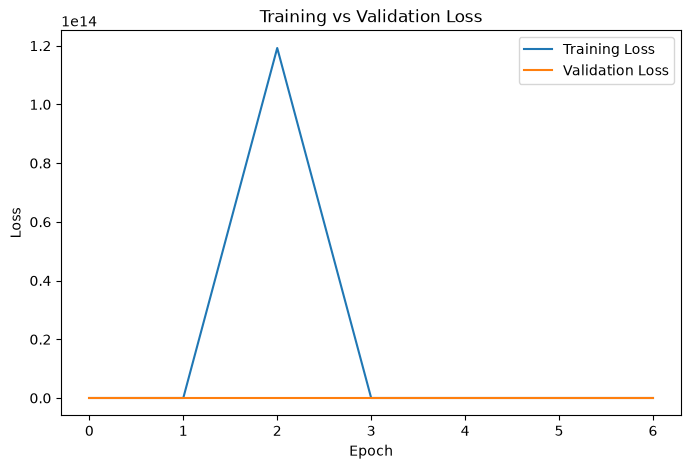

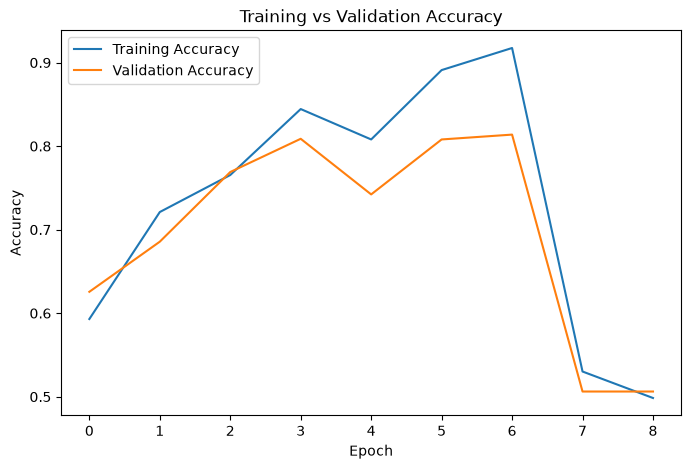

In [66]:
history_data = history.history

plt.figure(figsize=(8, 5))
plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_data["accuracy"], label="Training Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## 12. Evaluate on the Test Set

The test set has not been used for model fitting or validation. It therefore provides the final estimate of performance on unseen reviews.

In [67]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7993 - loss: 0.4568
Test Loss: 0.4568
Test Accuracy: 0.7993


## 13. Save the Trained Model

The notebook is stored inside the `notebooks/` directory, while trained models belong in the project's `models/` directory.

Because the current working directory can vary between VS Code/Jupyter configurations, the code below detects the project root and creates the `models/` directory when necessary.

Two formats are saved:
- `.keras` → preferred modern Keras format
- `.h5` → retained for compatibility with the current Streamlit inference workflow

In [69]:
from pathlib import Path

In [70]:
project_root = Path.cwd()

# If the notebook is running from the notebooks/ directory, move to the project root.
if not (project_root / "models").exists() and (project_root.parent / "models").exists():
    project_root = project_root.parent

model_dir = project_root / "models"
model_dir.mkdir(parents=True, exist_ok=True)

keras_path = model_dir / "simple_rnn_imdb.keras"
h5_path = model_dir / "simple_rnn_imdb.h5"

model.save(keras_path)
model.save(h5_path)

print("Keras model:", keras_path.resolve())
print("H5 model:   ", h5_path.resolve())

Keras model: E:\imdb-movie-review-sentiment-analysis-simple-rnn\models\simple_rnn_imdb.keras
H5 model:    E:\imdb-movie-review-sentiment-analysis-simple-rnn\models\simple_rnn_imdb.h5


## Key Takeaways

- The IMDB reviews are represented as integer token sequences.
- Padding converts variable-length reviews into fixed-length inputs.
- The Embedding layer converts token IDs into dense vectors.
- The Simple RNN learns sequential information from the embedded review.
- A sigmoid output is used for binary sentiment classification.
- Early Stopping helps reduce unnecessary training and can limit overfitting.
- The trained model is saved for the prediction and Streamlit stages.

### Next Step

The saved model will be loaded in the prediction notebook, where new user-provided reviews will be preprocessed and classified as **Positive** or **Negative**.